This notebook implements the Reptile meta-learning algorithm for few-shot image classification on the Omniglot dataset. The goal is to train a convolutional neural network such that it can quickly adapt to new classification tasks (5-way, 5-shot) using only a small number of examples per class.

The workflow includes building an episodic task sampler, performing inner-loop adaptation on support sets, and updating a meta-model across many sampled tasks using the Reptile algorithm.

We experiment with different training configurations such as inner-loop learning rate, number of inner steps, meta learning rate, and other hyperparameters to study their impact on generalization. The notebook also includes validation-based model selection and evaluation on unseen test tasks to assess how well the learned initialization transfers to new classes.

# Importing Essential Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random
from torchvision import transforms
import torch.optim as optim
import copy

#### Key Concepts in Preprocessing and Understanding the Dataset

- In the Omniglot dataset, we ignore the alphabet names and treat each character as an independent class (e.g., character01, character02, etc.).
- This means:
  - Each character = one class
  - Each class contains multiple images (typically ~20)
- We organize the dataset as: class_id → list of image tensors
- Once this mapping is built, we can construct episodic tasks.

---

#### Task Construction (5-way, 5-shot)

For a 5-way, 5-shot task:
- We randomly sample 5 classes
- For each class:
  - 5 images → support set
  - 5 images → query set

Example:
Selected classes → [12, 45, 67, 8, 91]

- Support set:
  - 5 classes × 5 images = 25 images
- Query set:
  - 5 classes × 5 images = 25 images

---

#### Meta-Learning Setup

We focus on the 5-way, 5-shot classification setting, where the model must adapt to new tasks using only a small number of labeled examples per class.

---

## Reptile Algorithm Workflow

### Step 0: Sample a Task

Example classes:
- Class A → Bengali character
- Class B → Greek character
- Class C → Cyrillic character
- Class D → Armenian character
- Class E → Balinese character

---

### Step 1: Build Support Set

5 classes × 5 images = 25 images

support_x = [img_A1, ..., img_A5, img_B1, ..., img_B5, ..., img_E1, ..., img_E5]

support_y = [0,0,0,0,0, 1,1,1,1,1, ..., 4,4,4,4,4]

---

### Step 2: Build Query Set

5 classes × 5 images = 25 images

query_x = [img_A6, ..., img_A10, ..., img_E6, ..., img_E10]

query_y = [0,...,4]

---

### Step 3: Initialize Meta-Model

φ  (shared initialization across all tasks)

---

### Step 4: Inner Loop (Task Adaptation)

W = copy(φ)

for k steps:
    logits = model(support_x)
    loss = cross_entropy(logits, support_y)
    W = W - α * ∇W loss

---

### Step 5: Evaluate on Query Set

logits = model(query_x)
loss_query = cross_entropy(logits, query_y)
accuracy = ...

---

### Step 6: Outer Update (Reptile Update)

φ ← φ + ε (W − φ)

- The meta-model is updated towards the task-adapted weights
- This allows the model to learn a good initialization for fast adaptation

# Dataset Preparation

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Data Preprocessing

In this step, we define a transformation pipeline to preprocess all Omniglot images before feeding them into the model.

- Resize: All images are resized to 28 × 28 to maintain a consistent input size.

- ToTensor: Converts images into PyTorch tensors with pixel values in the range [0, 1].

- Invert Colors: The transformation (1 − x) inverts the image, making characters white on a dark background, which is a common preprocessing step for Omniglot.

- Normalize: Pixel values are normalized to have mean ≈ 0 and standard deviation ≈ 1, which helps improve training stability and convergence.

In [3]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.RandomAffine(10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),
])

In [4]:
train_root = "/kaggle/input/datasets/watesoyan/omniglot/images_background"
test_root  = "/kaggle/input/datasets/watesoyan/omniglot/images_evaluation"

In [5]:
import os

def count_images(root_dir):
    count = 0
    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)

        if not os.path.isdir(alphabet_path):
            continue

        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)

            if not os.path.isdir(character_path):
                continue

            count += len(os.listdir(character_path))

    return count


print("Train Samples:", count_images(train_root))
print("Test Samples:", count_images(test_root))

Train Samples: 19280
Test Samples: 13180


In [6]:
def count_images_per_class(root_dir):
    counts = []
    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue

        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)
            if not os.path.isdir(character_path):
                continue

            counts.append(len(os.listdir(character_path)))

    return counts


counts = count_images_per_class(train_root)
print("Min images per class:", min(counts))
print("Max images per class:", max(counts))

Min images per class: 20
Max images per class: 20


📂 Building Class-wise Dataset and Meta-Splits

In this step, the Omniglot dataset is reorganized into a format suitable for meta-learning by grouping images according to their character classes. The `build_class_dict` function iterates through the dataset directory, loads each image in grayscale, applies the preprocessing transformations, and stores them in a dictionary where each key represents a unique class (alphabet/character) and maps to all corresponding image tensors. This structure enables efficient sampling of tasks during meta-training.

After constructing the full dataset, the training classes are randomly shuffled and split into meta-train (80%) and meta-validation (20%) sets, while the test classes are kept completely separate. This ensures that the model is trained and validated on different sets of classes, and finally evaluated on entirely unseen classes, which is crucial for assessing few-shot generalization.

In [7]:
import os
import random
from PIL import Image

def build_class_dict(root_dir, transform):
    class_dict = {}

    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue

        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)
            if not os.path.isdir(character_path):
                continue

            original_images = []
            for img_name in os.listdir(character_path):
                img_path = os.path.join(character_path, img_name)
                if not os.path.isfile(img_path):
                    continue

                image = Image.open(img_path).convert("L")
                image_tensor = transform(image)
                
                original_images.append(image_tensor)

            base_class_id = f"{alphabet}/{character}"
            class_dict[base_class_id] = original_images

    return class_dict


train_classes_full = build_class_dict(train_root, transform)
test_classes = build_class_dict(test_root, transform)

all_train_class_ids = list(train_classes_full.keys())
random.seed(42)
random.shuffle(all_train_class_ids)

val_fraction = 0.2
num_val = int(len(all_train_class_ids) * val_fraction)

val_class_ids = all_train_class_ids[:num_val]
train_class_ids = all_train_class_ids[num_val:]

train_classes = {cid: train_classes_full[cid] for cid in train_class_ids}
val_classes = {cid: train_classes_full[cid] for cid in val_class_ids}

print("Meta-train classes:", len(train_classes))
print("Meta-val classes:", len(val_classes))
print("Meta-test classes:", len(test_classes))
min_images = min(len(v) for v in train_classes.values())
print("Min images per class (train):", min_images)

Meta-train classes: 772
Meta-val classes: 192
Meta-test classes: 659
Min images per class (train): 20


🎯 Task Sampling for Few-Shot Learning

This class implements an episodic task sampler, which is central to meta-learning. Instead of training on the entire dataset at once, the model is trained on many small tasks that mimic the few-shot setting.

For each task, the sampler randomly selects N classes (n-way) and, for each class, samples a small number of images. These are split into:

a support set (used for inner-loop adaptation), and
a query set (used to evaluate how well the model adapts).

Labels are assigned locally (from 0 to N−1) within each task, ensuring that every task is treated as a new classification problem. The output tensors (support_x, support_y, query_x, query_y) are then used during meta-training, allowing the model to repeatedly practice adapting to new tasks with limited data.

In [8]:
import random
import torch

class OmniglotTaskSampler:
    def __init__(self, class_to_images):
        """
        class_to_images:
            dict where
            key   = class_id
            value = list of image tensors
        """
        self.class_to_images = class_to_images
        self.class_ids = list(class_to_images.keys())

    def sample_task(self, n_way=5, k_shot=10, q_query=5):
        """
        Sample one N-way K-shot task.

        Returns:
            support_x: tensor of shape [n_way * k_shot, 1, 28, 28]
            support_y: tensor of shape [n_way * k_shot]
            query_x:   tensor of shape [n_way * q_query, 1, 28, 28]
            query_y:   tensor of shape [n_way * q_query]
        """

        selected_classes = random.sample(self.class_ids, n_way)

        support_images = []
        support_labels = []
        query_images = []
        query_labels = []

        for local_label, class_id in enumerate(selected_classes):
            images = self.class_to_images[class_id]
            total_needed = k_shot + q_query

            if len(images) < total_needed:
                raise ValueError(
                    f"Class {class_id} has only {len(images)} images, "
                    f"but {total_needed} are required."
                )

            sampled_images = random.sample(images, total_needed)

            support_imgs = sampled_images[:k_shot]
            query_imgs = sampled_images[k_shot:]

            support_images.extend(support_imgs)
            query_images.extend(query_imgs)

            support_labels.extend([local_label] * k_shot)
            query_labels.extend([local_label] * q_query)

        support_x = torch.stack(support_images)
        support_y = torch.tensor(support_labels, dtype=torch.long)

        query_x = torch.stack(query_images)
        query_y = torch.tensor(query_labels, dtype=torch.long)

        return support_x, support_y, query_x, query_y

In [9]:
train_sampler = OmniglotTaskSampler(train_classes)
val_sampler = OmniglotTaskSampler(val_classes)
test_sampler = OmniglotTaskSampler(test_classes)

In [14]:
import matplotlib.pyplot as plt

def visualize_task(support_x, support_y, query_x, query_y, n_way=5, k_shot=None, q_query=5):

    if k_shot is None:
        k_shot = len(support_x) // n_way  # auto-infer

    total_cols = max(n_way * k_shot, n_way * q_query)

    plt.figure(figsize=(15, 4))

    # ---- Support set ----
    for i in range(n_way * k_shot):
        plt.subplot(2, total_cols, i + 1)
        plt.imshow(support_x[i].squeeze(0), cmap="gray")
        plt.title(f"S:{support_y[i].item()}")
        plt.axis("off")

    # ---- Query set ----
    for i in range(n_way * q_query):
        plt.subplot(2, total_cols, total_cols + i + 1)
        plt.imshow(query_x[i].squeeze(0), cmap="gray")
        plt.title(f"Q:{query_y[i].item()}")
        plt.axis("off")

    plt.suptitle("Support (Top) vs Query (Bottom)")
    plt.tight_layout()
    plt.show()

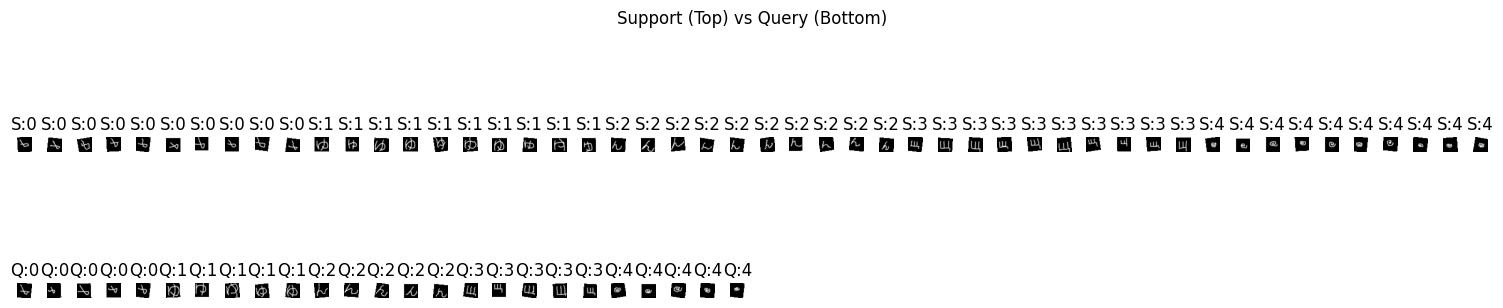

In [15]:
support_x, support_y, query_x, query_y = train_sampler.sample_task(
    n_way=5,
    k_shot=10,   # changed
    q_query=5
)

visualize_task(
    support_x, support_y,
    query_x, query_y,
    n_way=5,
    q_query=5   # k_shot auto-inferred now
)

In [16]:
support_x, support_y, query_x, query_y = train_sampler.sample_task(
    n_way=5,
    k_shot=10,
    q_query=5
)

print("Support labels:", support_y)
print("Query labels:", query_y)
print("Unique support labels:", torch.unique(support_y))
print("Unique query labels:", torch.unique(query_y))

Support labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4])
Query labels: tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
        4])
Unique support labels: tensor([0, 1, 2, 3, 4])
Unique query labels: tensor([0, 1, 2, 3, 4])


In [17]:
print("Support label set:", set(support_y.tolist()))
print("Query label set:", set(query_y.tolist()))

Support label set: {0, 1, 2, 3, 4}
Query label set: {0, 1, 2, 3, 4}


# Model 

🧠 Model Architecture (CNN for Few-Shot Learning)

This section defines the convolutional neural network used as the base model for meta-learning. The architecture consists of repeated ConvBlocks, each containing a convolution layer, ReLU activation, and max pooling. These blocks progressively extract higher-level features from the input images while reducing spatial dimensions.

The full model (OmniglotCNN) stacks four such convolutional blocks, followed by a fully connected layer that maps the extracted features to class logits for an N-way classification task. Normalization layers (GroupNorm/BatchNorm) are currently commented out, as they were experimented with but found to affect stability in this few-shot setting. This lightweight architecture is commonly used in meta-learning due to its simplicity and effectiveness on datasets like Omniglot.

In [18]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

    def forward(self, x):
        return self.block(x)


class OmniglotCNN(nn.Module):
    def __init__(self, n_way):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 64),
            ConvBlock(64, 64),
            ConvBlock(64, 64),
            ConvBlock(64, 64)
        )
        self.classifier = nn.Linear(64, n_way)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits

🔁 Inner-Loop Adaptation (Task-Specific Learning)

This function performs the inner-loop optimization for a single sampled task, which is a key component of the Reptile algorithm. Starting from the meta-model, a copy of the model (task_model) is created and trained on the task’s support set for a few gradient steps.

Using the support images and labels (5-shot per class), the model is updated via gradient descent (Adam optimizer) for a fixed number of steps (inner_steps). This simulates how the model adapts to a new task using only a small number of examples per class.

The final adapted model and the last support loss are returned, which are then used in the outer-loop (meta-update) to improve the shared initialization so that it can quickly adapt to new unseen tasks.

In [19]:
criterion = nn.CrossEntropyLoss()

def adapt_on_task(
    meta_model,
    support_x,
    support_y,
    inner_lr=0.001,
    inner_steps=5,
    inner_batch_size=10
):
    support_x = support_x.to(device)
    support_y = support_y.to(device)

    task_model = copy.deepcopy(meta_model)
    task_model.train()

    optimizer = torch.optim.Adam(
        task_model.parameters(),
        lr=inner_lr,
        betas=(0.0, 0.999)
    )

    support_loss_value = None
    num_support = support_x.size(0)

    for _ in range(inner_steps):
        perm = torch.randperm(num_support, device=device)

        for start in range(0, num_support, inner_batch_size):
            batch_idx = perm[start:start + inner_batch_size]
            x_batch = support_x[batch_idx]
            y_batch = support_y[batch_idx]

            optimizer.zero_grad()
            logits = task_model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            support_loss_value = loss.item()

    return task_model, support_loss_value

🔄 Computing Task-Specific Updates (Reptile Delta)

This function computes the parameter difference between the adapted task model and the original meta-model. For each parameter, it calculatesW−ϕ, where ϕ represents the meta-model parameters and W represents the task-adapted parameters.

This difference (delta) captures how the model needs to change to perform well on a specific task. In the Reptile algorithm, these deltas are averaged across multiple tasks and used to update the meta-model, effectively moving it toward parameters that can quickly adapt to new tasks. The .detach() ensures that these updates are treated as fixed values and do not track gradients during the meta-update.

In [20]:
def compute_task_delta(meta_model, task_model):
    return [
        (task_param - meta_param).detach()
        for meta_param, task_param in zip(meta_model.parameters(), task_model.parameters())
    ]

In [21]:
criterion = nn.CrossEntropyLoss()

def evaluate_task(
    meta_model,
    support_x,
    support_y,
    query_x,
    query_y,
    inner_lr=0.001,
    inner_steps=50,           # changed
    inner_batch_size=10       # added
):
    support_x = support_x.to(device)
    support_y = support_y.to(device)
    query_x = query_x.to(device)
    query_y = query_y.to(device)

    task_model, _ = adapt_on_task(
        meta_model=meta_model,
        support_x=support_x,
        support_y=support_y,
        inner_lr=inner_lr,
        inner_steps=inner_steps,
        inner_batch_size=inner_batch_size   # added
    )

    task_model.eval()
    with torch.no_grad():
        query_logits = task_model(query_x)
        query_loss = criterion(query_logits, query_y).item()
        query_preds = query_logits.argmax(dim=1)
        query_acc = (query_preds == query_y).float().mean().item()

    return query_loss, query_acc

📈 Evaluating Across Multiple Tasks

This function evaluates the meta-model over multiple randomly sampled tasks to obtain a reliable estimate of its performance. Instead of relying on a single task, it repeatedly samples tasks using the task sampler and computes the query loss and accuracy for each one.

For each sampled task, the model is adapted on the support set and evaluated on the query set using evaluate_task. The losses and accuracies are collected and averaged across all tasks to produce:

Average query loss
Average query accuracy

This provides a more stable and meaningful measure of how well the meta-learned model generalizes to new, unseen tasks in the few-shot setting.

In [22]:
def evaluate_many_tasks(
    meta_model,
    test_sampler,
    num_tasks=100,
    n_way=5,
    k_shot=5,
    q_query=5,
    inner_lr=0.001,
    inner_steps=50,        
    inner_batch_size=10     
):
    losses = []
    accs = []

    for _ in range(num_tasks):
        support_x, support_y, query_x, query_y = test_sampler.sample_task(
            n_way=n_way,
            k_shot=k_shot,
            q_query=q_query
        )

        query_loss, query_acc = evaluate_task(
            meta_model=meta_model,
            support_x=support_x,
            support_y=support_y,
            query_x=query_x,
            query_y=query_y,
            inner_lr=inner_lr,
            inner_steps=inner_steps,
            inner_batch_size=inner_batch_size   
        )

        losses.append(query_loss)
        accs.append(query_acc)

    avg_loss = sum(losses) / len(losses)
    avg_acc = sum(accs) / len(accs)

    return avg_loss, avg_acc

In [23]:
def reptile_train(
    meta_model,
    train_sampler,
    val_sampler=None,
    meta_iters=10000,
    tasks_per_meta_batch=5,
    n_way=5,
    train_k_shot=10,
    eval_k_shot=5,
    q_query=5,
    inner_lr=0.001,
    inner_steps=5,
    inner_batch_size=10,
    meta_lr=0.01,
    eval_every=50,
    eval_tasks=100,
    eval_inner_lr=None,
    eval_inner_steps=50,
    eval_inner_batch_size=10,
    device="cuda"
):
    meta_model = meta_model.to(device)

    if eval_inner_lr is None:
        eval_inner_lr = inner_lr

    train_support_losses = []
    eval_query_losses = []
    eval_query_accuracies = []

    best_eval_acc = -1.0
    best_model_state = copy.deepcopy(meta_model.state_dict())

    for meta_iter in range(1, meta_iters + 1):
        meta_model.train()

        delta_sum = [torch.zeros_like(p, device=device) for p in meta_model.parameters()]
        meta_batch_support_losses = []

        for _ in range(tasks_per_meta_batch):
            support_x, support_y, _, _ = train_sampler.sample_task(
                n_way=n_way,
                k_shot=train_k_shot,
                q_query=q_query
            )

            task_model, support_loss_value = adapt_on_task(
                meta_model=meta_model,
                support_x=support_x,
                support_y=support_y,
                inner_lr=inner_lr,
                inner_steps=inner_steps,
                inner_batch_size=inner_batch_size
            )

            meta_batch_support_losses.append(support_loss_value)

            with torch.no_grad():
                for d_sum, meta_p, task_p in zip(delta_sum, meta_model.parameters(), task_model.parameters()):
                    d_sum.add_(task_p - meta_p)

        with torch.no_grad():
            for meta_p, d_sum in zip(meta_model.parameters(), delta_sum):
                meta_p.add_(meta_lr * (d_sum / tasks_per_meta_batch))

        avg_support_loss = sum(meta_batch_support_losses) / len(meta_batch_support_losses)
        train_support_losses.append(avg_support_loss)

        if meta_iter % eval_every == 0:
            sampler = val_sampler if val_sampler is not None else train_sampler

            eval_query_loss, eval_query_acc = evaluate_many_tasks(
                meta_model=meta_model,
                test_sampler=sampler,
                num_tasks=eval_tasks,
                n_way=n_way,
                k_shot=eval_k_shot,
                q_query=q_query,
                inner_lr=eval_inner_lr,
                inner_steps=eval_inner_steps,
                inner_batch_size=eval_inner_batch_size
            )

            eval_query_losses.append((meta_iter, eval_query_loss))
            eval_query_accuracies.append((meta_iter, eval_query_acc))

            print(
                f"[Meta-iter {meta_iter:5d}] "
                f"train_support_loss={avg_support_loss:.4f} | "
                f"eval_query_loss={eval_query_loss:.4f} | "
                f"eval_query_acc={eval_query_acc*100:.2f}%"
            )

            if eval_query_acc > best_eval_acc:
                best_eval_acc = eval_query_acc
                best_model_state = copy.deepcopy(meta_model.state_dict())

    meta_model.load_state_dict(best_model_state)

    history = {
        "train_support_losses": train_support_losses,
        "eval_query_losses": eval_query_losses,
        "eval_query_accuracies": eval_query_accuracies,
        "best_eval_acc": best_eval_acc
    }

    return meta_model, history

In [24]:
n_way = 5
train_k_shot = 10
eval_k_shot = 5
q_query = 5

meta_model = OmniglotCNN(n_way=n_way).to(device)

meta_model, history = reptile_train(
    meta_model=meta_model,
    train_sampler=train_sampler,
    val_sampler=val_sampler,
    meta_iters=10000,
    tasks_per_meta_batch=5,
    n_way=n_way,
    train_k_shot=train_k_shot,
    eval_k_shot=eval_k_shot,
    q_query=q_query,
    inner_lr=0.001,
    inner_steps=5,
    inner_batch_size=10,
    meta_lr=0.01,
    eval_every=50,
    eval_tasks=100,
    eval_inner_lr=0.001,
    eval_inner_steps=50,
    eval_inner_batch_size=10,
    device=device
)

avg_test_loss, avg_test_acc = evaluate_many_tasks(
    meta_model=meta_model,
    test_sampler=test_sampler,
    num_tasks=500,
    n_way=n_way,
    k_shot=eval_k_shot,
    q_query=q_query,
    inner_lr=0.001,
    inner_steps=50,
    inner_batch_size=10
)

print("Average test query loss:", avg_test_loss)
print("Average test query accuracy:", avg_test_acc)

[Meta-iter    50] train_support_loss=1.0323 | eval_query_loss=0.8655 | eval_query_acc=69.04%
[Meta-iter   100] train_support_loss=0.7294 | eval_query_loss=0.8820 | eval_query_acc=69.08%
[Meta-iter   150] train_support_loss=0.7655 | eval_query_loss=0.7987 | eval_query_acc=71.60%
[Meta-iter   200] train_support_loss=0.7075 | eval_query_loss=0.8206 | eval_query_acc=70.04%
[Meta-iter   250] train_support_loss=0.3274 | eval_query_loss=0.7766 | eval_query_acc=70.92%
[Meta-iter   300] train_support_loss=0.3843 | eval_query_loss=0.7320 | eval_query_acc=73.36%
[Meta-iter   350] train_support_loss=0.1954 | eval_query_loss=0.6898 | eval_query_acc=75.76%
[Meta-iter   400] train_support_loss=0.2137 | eval_query_loss=0.6688 | eval_query_acc=76.16%
[Meta-iter   450] train_support_loss=0.1046 | eval_query_loss=0.6473 | eval_query_acc=77.52%
[Meta-iter   500] train_support_loss=0.1062 | eval_query_loss=0.6408 | eval_query_acc=77.48%
[Meta-iter   550] train_support_loss=0.0905 | eval_query_loss=0.6439 |

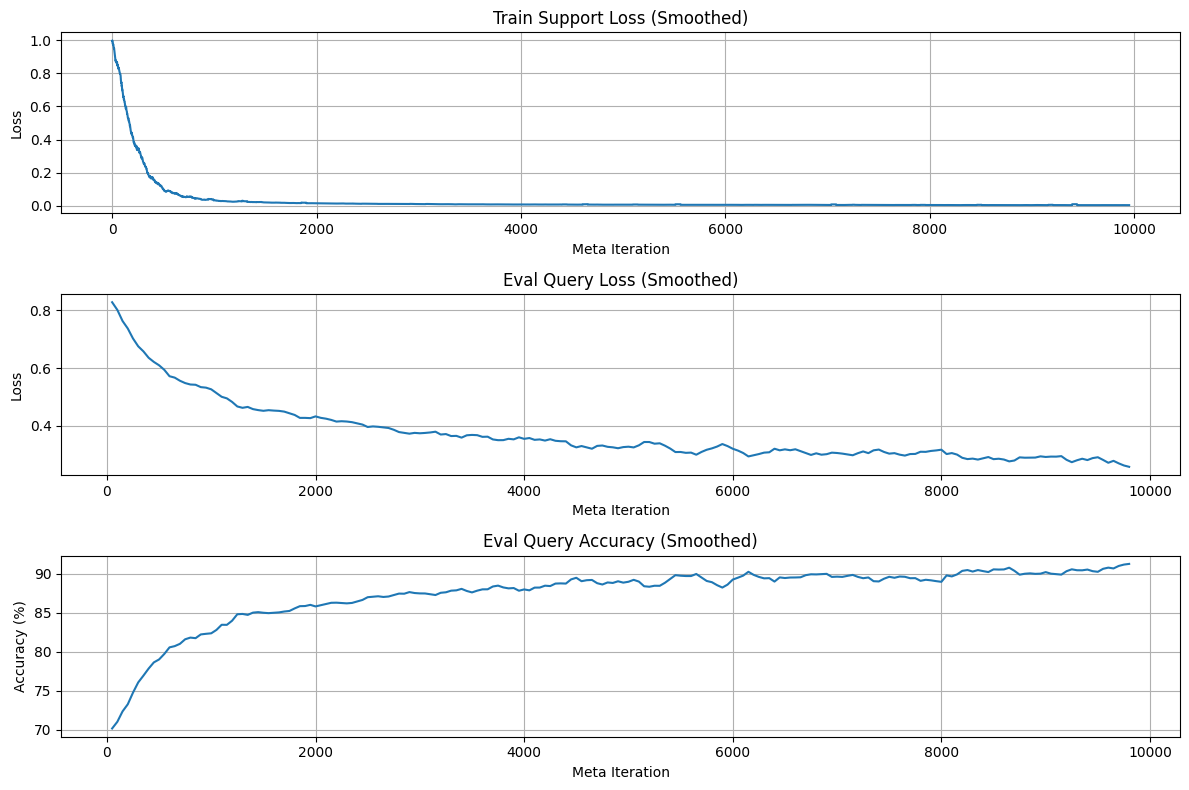

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(x, window=20):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')


# ---- Extract data ----
train_losses = history["train_support_losses"]

eval_meta_iters_loss = [x[0] for x in history["eval_query_losses"]]
eval_losses = [x[1] for x in history["eval_query_losses"]]

eval_meta_iters_acc = [x[0] for x in history["eval_query_accuracies"]]
eval_accs = [x[1] for x in history["eval_query_accuracies"]]


# ---- Smooth curves ----
smooth_train_losses = moving_average(train_losses, window=50)
smooth_eval_losses = moving_average(eval_losses, window=5)
smooth_eval_accs = moving_average(eval_accs, window=5)


# ---- Plot everything together ----
plt.figure(figsize=(12, 8))

# --- Train loss ---
plt.subplot(3, 1, 1)
plt.plot(smooth_train_losses)
plt.title("Train Support Loss (Smoothed)")
plt.xlabel("Meta Iteration")
plt.ylabel("Loss")
plt.grid(True)

# --- Eval loss ---
plt.subplot(3, 1, 2)
plt.plot(eval_meta_iters_loss[:len(smooth_eval_losses)], smooth_eval_losses)
plt.title("Eval Query Loss (Smoothed)")
plt.xlabel("Meta Iteration")
plt.ylabel("Loss")
plt.grid(True)

# --- Eval accuracy ---
plt.subplot(3, 1, 3)
plt.plot(eval_meta_iters_acc[:len(smooth_eval_accs)], np.array(smooth_eval_accs) * 100)
plt.title("Eval Query Accuracy (Smoothed)")
plt.xlabel("Meta Iteration")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

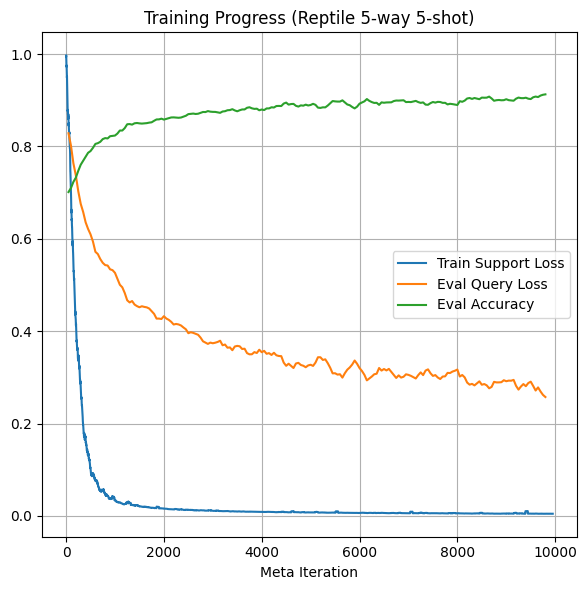

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(x, window=20):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')


# ---- Extract data ----
train_losses = history["train_support_losses"]

eval_meta_iters_loss = [x[0] for x in history["eval_query_losses"]]
eval_losses = [x[1] for x in history["eval_query_losses"]]

eval_meta_iters_acc = [x[0] for x in history["eval_query_accuracies"]]
eval_accs = [x[1] for x in history["eval_query_accuracies"]]


# ---- Smooth ----
smooth_train_losses = moving_average(train_losses, window=50)
smooth_eval_losses = moving_average(eval_losses, window=5)
smooth_eval_accs = moving_average(eval_accs, window=5)


# ---- Plot ----
plt.figure(figsize=(6, 6))  # 👈 square plot

# Train loss
plt.plot(smooth_train_losses, label="Train Support Loss")

# Eval loss
plt.plot(
    eval_meta_iters_loss[:len(smooth_eval_losses)],
    smooth_eval_losses,
    label="Eval Query Loss"
)

# Eval accuracy (scaled to match loss range)
plt.plot(
    eval_meta_iters_acc[:len(smooth_eval_accs)],
    np.array(smooth_eval_accs),
    label="Eval Accuracy"
)

plt.xlabel("Meta Iteration")
plt.title("Training Progress (Reptile 5-way 5-shot)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

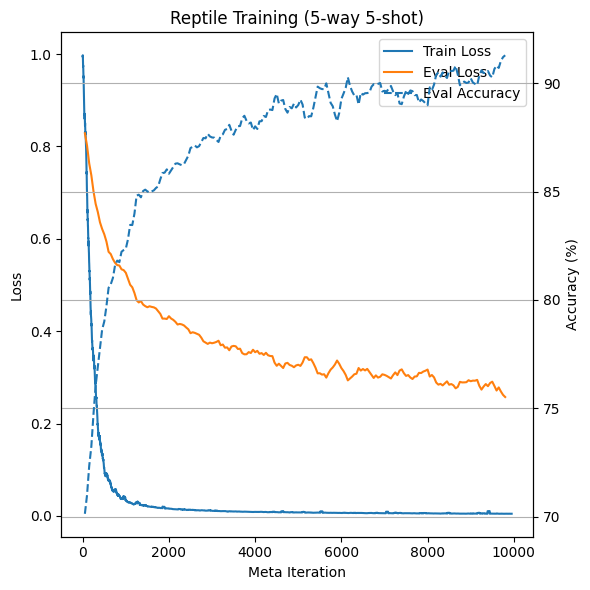

In [27]:
fig, ax1 = plt.subplots(figsize=(6, 6))

# Loss axis
ax1.plot(smooth_train_losses, label="Train Loss")
ax1.plot(
    eval_meta_iters_loss[:len(smooth_eval_losses)],
    smooth_eval_losses,
    label="Eval Loss"
)
ax1.set_xlabel("Meta Iteration")
ax1.set_ylabel("Loss")

# Accuracy axis
ax2 = ax1.twinx()
ax2.plot(
    eval_meta_iters_acc[:len(smooth_eval_accs)],
    np.array(smooth_eval_accs) * 100,
    linestyle='--',
    label="Eval Accuracy"
)
ax2.set_ylabel("Accuracy (%)")

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.title("Reptile Training (5-way 5-shot)")
plt.grid(True)
plt.tight_layout()
plt.show()